Analysis, Visualisation and Interpretation

**Processing objective:** Which NYC taxi routes experience the highest levels of congestion during peak hours, and how does congestion affect revenue generated on these routes?


**Definitions inherited from mapreduce:**
- **Free flow:** weekday 01:00-04:59 speed on the route.
- **Peak:** weekdays 07:00-09:59 (AM) and 16:00-18:59 (PM).
- **Travel-time index (TTI):** free-flow speed ÷ actual speed. A TTI of 1.5 means trips take 50% longer than at free flow.
- **Delay hours:** actual hours − hours the same miles would take at free flow.

###Loading mapreduce part output files

In [2]:
!git clone https://github.com/ShreyaB143/MIT805-GroupProject.git
%cd MIT805-GroupProject
!ls output

Cloning into 'MIT805-GroupProject'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (183/183), done.
remote: Total 240 (delta 109), reused 165 (delta 50), pack-reused 0 (from 0)
Receiving objects: 100% (240/240), 9.89 MiB | 20.38 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/MIT805-GroupProject
distance_distribution.csv  plan_rq2_route_window.txt
filtered_schema.txt	   rq1_zone_hour.csv
hourly_profile.csv	   rq2_route_window.csv
hourly_yield.csv	   schema_by_month.csv
monthly_volume.csv	   sensitivity.csv
part2_summary.csv	   stage_metrics.csv
part2_summary.json	   stage_metrics_significant.csv
plan_rq1_zone_hour.txt	   zone_counts.csv


In [3]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


REPO = Path.cwd()
OUT, FIG = REPO / "output", REPO / "figures"
FIG.mkdir(exist_ok=True)

AIRPORTS = [132, 138]  # JFK, LaGuardia
PEAKS = {"am_peak": "AM peak", "pm_peak": "PM peak"}

plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight", "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 170, "display.max_colwidth", 45)

def save(fig, name):
    # PNG for the video and slides, PDF (vector) for Overleaf
    fig.savefig(FIG / f"{name}.png")
    fig.savefig(FIG / f"{name}.pdf")
    plt.show()

def short(s, n=20):
    s = str(s)
    return s if len(s) <= n else s[: n - 1] + "…"

rq2  = pd.read_csv(OUT / "rq2_route_window.csv")
rq1  = pd.read_csv(OUT / "rq1_zone_hour.csv")
sens = pd.read_csv(OUT / "sensitivity.csv")

for name, df in [("rq2_route_window", rq2), ("rq1_zone_hour", rq1), ("sensitivity", sens)]:
    print(f"{name}: {len(df):,} rows x {df.shape[1]} columns")
    print("   ", list(df.columns))

rq2_route_window: 14,514 rows x 17 columns
    ['do', 'pu', 'window', 'm', 'h', 'rev', 'trips', 'speed', 'ff_speed', 'n_night', 'tti', 'delay_hr_total', 'delay_min_per_trip', 'pu_zone', 'pu_boro', 'do_zone', 'do_boro']
rq1_zone_hour: 12,173 rows x 15 columns
    ['pu', 'hour', 'daytype', 'rev', 'hours', 'miles', 'delay_hr', 'trips', 'yield_hr', 'speed', 'ff_yield_zone', 'yield_gap', 'forgone', 'zone', 'borough']
sensitivity: 4 rows x 6 columns
    ['variant', 'trips', 'slowest_hour', 'min_speed', 'peak_yield', 'trough_yield']


## Check the inputs



In [4]:
need = {
    "rq2": (rq2, {"pu", "do", "window", "m", "h", "rev", "trips", "speed",
                  "ff_speed", "tti", "delay_hr_total", "pu_zone", "do_zone"}),
    "rq1": (rq1, {"pu", "hour", "daytype", "rev", "hours", "miles", "delay_hr", "trips"}),
}
for k, (df, cols) in need.items():
    missing = cols - set(df.columns)
    print(f"{k}: {'all required columns present' if not missing else f'MISSING {missing}'}")

print("\nRoute-window cells per time window:")
print(rq2.window.value_counts().to_string())

summary_path = OUT / "part2_summary.json"
if summary_path.exists():
    s = json.loads(summary_path.read_text())
    print("\nMatches Person 1's route-window count:", len(rq2) == s["route_window_cells"])

rq2: all required columns present
rq1: all required columns present

Route-window cells per time window:
window
night      3450
weekend    3435
midday     2799
pm_peak    2627
am_peak    2203

Matches Person 1's route-window count: True


##Building route-level metrics


- average duration and average distance per trip
- revenue per trip, and revenue per vehicle-hour (how much a cab earns for each hour it spends on that route)
- share of trip time lost to congestion



In [5]:
rq2["route"] = [f"{short(a)} → {short(b)}" for a, b in zip(rq2.pu_zone, rq2.do_zone)]
rq2["airport_route"] = rq2.pu.isin(AIRPORTS) | rq2.do.isin(AIRPORTS)
rq2["avg_duration_min"] = rq2.h / rq2.trips * 60
rq2["avg_miles"] = rq2.m / rq2.trips
rq2["rev_per_trip"] = rq2.rev / rq2.trips
rq2["rev_per_hr"] = rq2.rev / rq2.h
rq2["delay_share"] = rq2.delay_hr_total / rq2.h

peak = rq2[rq2.window.isin(PEAKS)].copy()

routes = (peak.groupby(["pu", "do", "route", "pu_zone", "do_zone", "airport_route"], as_index=False)
              .agg(m=("m", "sum"), h=("h", "sum"), rev=("rev", "sum"), trips=("trips", "sum"),
                   delay_hr_total=("delay_hr_total", "sum"), ff_speed=("ff_speed", "first")))
routes["speed"] = routes.m / routes.h
routes["tti"] = routes.ff_speed / routes.speed
routes["avg_duration_min"] = routes.h / routes.trips * 60
routes["rev_per_trip"] = routes.rev / routes.trips
routes["rev_per_hr"] = routes.rev / routes.h


tti_w = (peak.pivot_table(index=["pu", "do"], columns="window", values="tti")
             .reindex(columns=list(PEAKS)).add_prefix("tti_").reset_index())
routes = routes.merge(tti_w, on=["pu", "do"], how="left")

print(f"Routes with peak-hour data: {len(routes):,}")
print(f"  in AM peak: {routes.tti_am_peak.notna().sum():,} | in PM peak: {routes.tti_pm_peak.notna().sum():,}")
print("\nMedian TTI by window (all windows, for context):")
print(rq2.groupby("window").tti.median().sort_values(ascending=False).round(2).to_string())

SHOW = ["route", "trips", "ff_speed", "speed", "tti", "tti_am_peak", "tti_pm_peak",
        "avg_duration_min", "rev_per_trip", "rev_per_hr", "delay_hr_total"]
routes.nlargest(10, "tti")[SHOW].round(2)

Routes with peak-hour data: 2,686
  in AM peak: 2,203 | in PM peak: 2,627

Median TTI by window (all windows, for context):
window
pm_peak    1.71
midday     1.70
am_peak    1.52
weekend    1.31
night      1.23


,route,trips,ff_speed,speed,tti,tti_am_peak,tti_pm_peak,avg_duration_min,rev_per_trip,rev_per_hr,delay_hr_total
1903,Penn Station/Madiso… → Times Sq/Theatre Di…,91030,12.35,4.78,2.58,2.28,2.89,13.16,14.24,64.93,12237.58
1062,LaGuardia Airport → Downtown Brooklyn/M…,6164,36.30,14.41,2.52,2.43,2.56,42.20,53.34,75.84,2614.22
1923,Seaport → JFK Airport,780,37.48,15.24,2.46,NaN,2.46,70.95,78.17,66.11,547.27
486,Flatiron → Times Sq/Theatre Di…,21726,14.55,6.09,2.39,1.93,2.76,14.47,15.63,64.80,3046.73
1994,Sunnyside → JFK Airport,2761,40.31,16.87,2.39,1.65,2.65,45.66,88.57,116.39,1221.66
1871,Penn Station/Madiso… → Garment District,22490,10.23,4.29,2.39,2.13,2.67,9.19,10.89,71.05,2002.57
1049,LaGuardia Airport → Brooklyn Heights,5756,35.70,14.97,2.38,2.20,2.44,42.68,55.49,78.00,2377.31
1071,LaGuardia Airport → Flatbush/Ditmas Park,2524,34.25,14.38,2.38,1.94,2.54,62.02,74.68,72.24,1513.27
260,East Chelsea → Times Sq/Theatre Di…,44558,13.18,5.54,2.38,2.43,2.36,14.79,15.94,64.64,6368.16
459,Flatiron → Garment District,14866,14.30,6.04,2.37,1.95,2.65,9.91,11.89,72.02,1418.35


## Top 10 congested routes
Congestion is ranked using the following:

**Severity (TTI):** how much slower the route is than at free flow.

**Burden (total delay hours):** severity × volume.


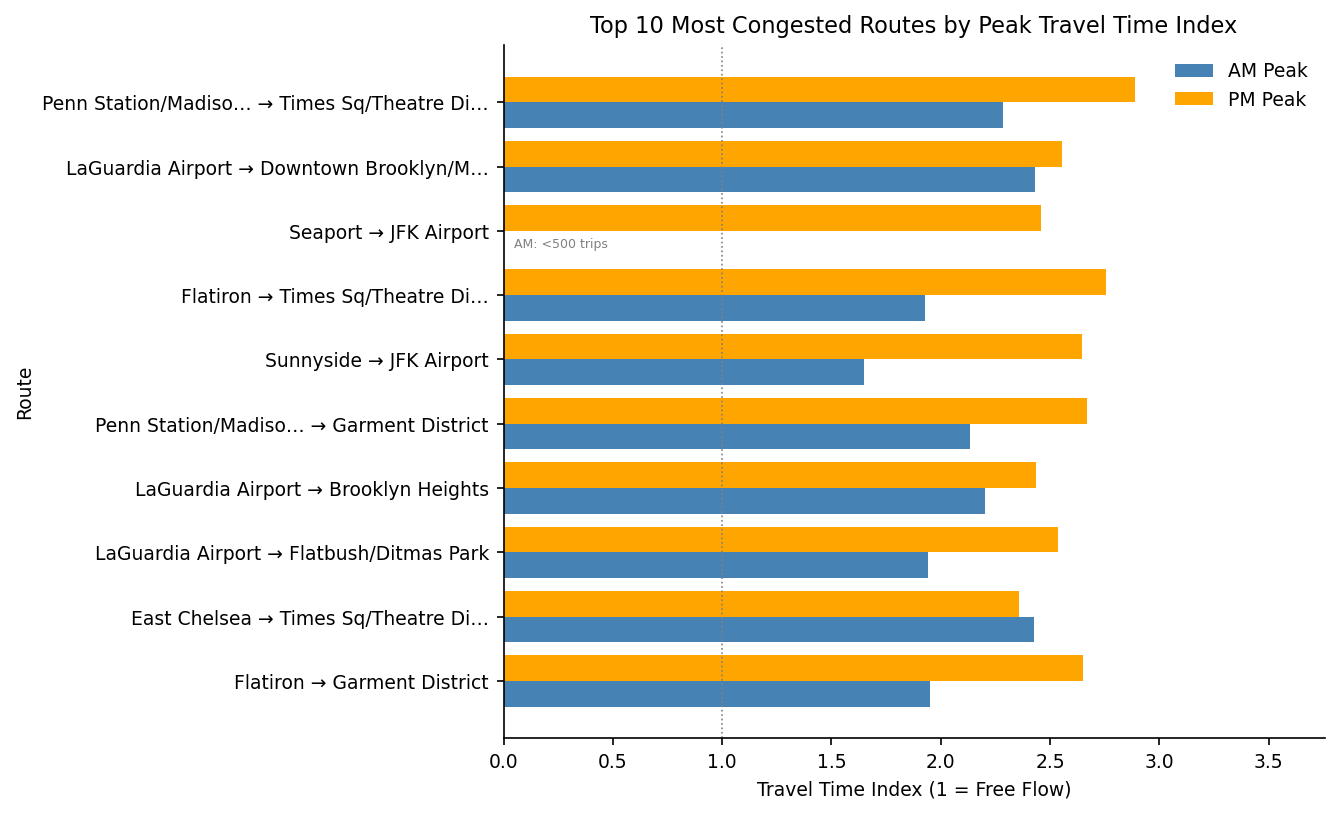

In [7]:

# FIGURE 1: TOP 10 MOST CONGESTED ROUTES (PEAK TTI)

top_tti = routes.nlargest(10, "tti")

fig, ax = plt.subplots(figsize=(9, 5.5))

d = top_tti.iloc[::-1]
y = np.arange(len(d))

ax.barh(
    y - 0.2,
    d["tti_am_peak"],
    height=0.4,
    label="AM Peak",
    color="steelblue"
)

ax.barh(
    y + 0.2,
    d["tti_pm_peak"],
    height=0.4,
    label="PM Peak",
    color="orange"
)

ax.set_yticks(y)
ax.set_yticklabels(d["route"])

ax.axvline(
    1,
    color="grey",
    linewidth=0.8,
    linestyle=":"
)

# Add notes for routes with insufficient trips
for col, off, lab in [
    ("tti_am_peak", -0.2, "AM"),
    ("tti_pm_peak", 0.2, "PM")
]:
    for yi, v in zip(y, d[col]):
        if pd.isna(v):
            ax.text(
                0.05,
                yi + off,
                f"{lab}: <500 trips",
                fontsize=6,
                va="center",
                color="grey"
            )

max_tti = d[["tti_am_peak", "tti_pm_peak"]].max().max()

ax.set_xlim(0, max_tti * 1.3)
ax.set_xlabel("Travel Time Index (1 = Free Flow)")
ax.set_ylabel("Route")
ax.set_title("Top 10 Most Congested Routes by Peak Travel Time Index")

ax.legend(frameon=False)

plt.tight_layout()
save(fig, "fig1_top_congested_routes_tti")
plt.show()

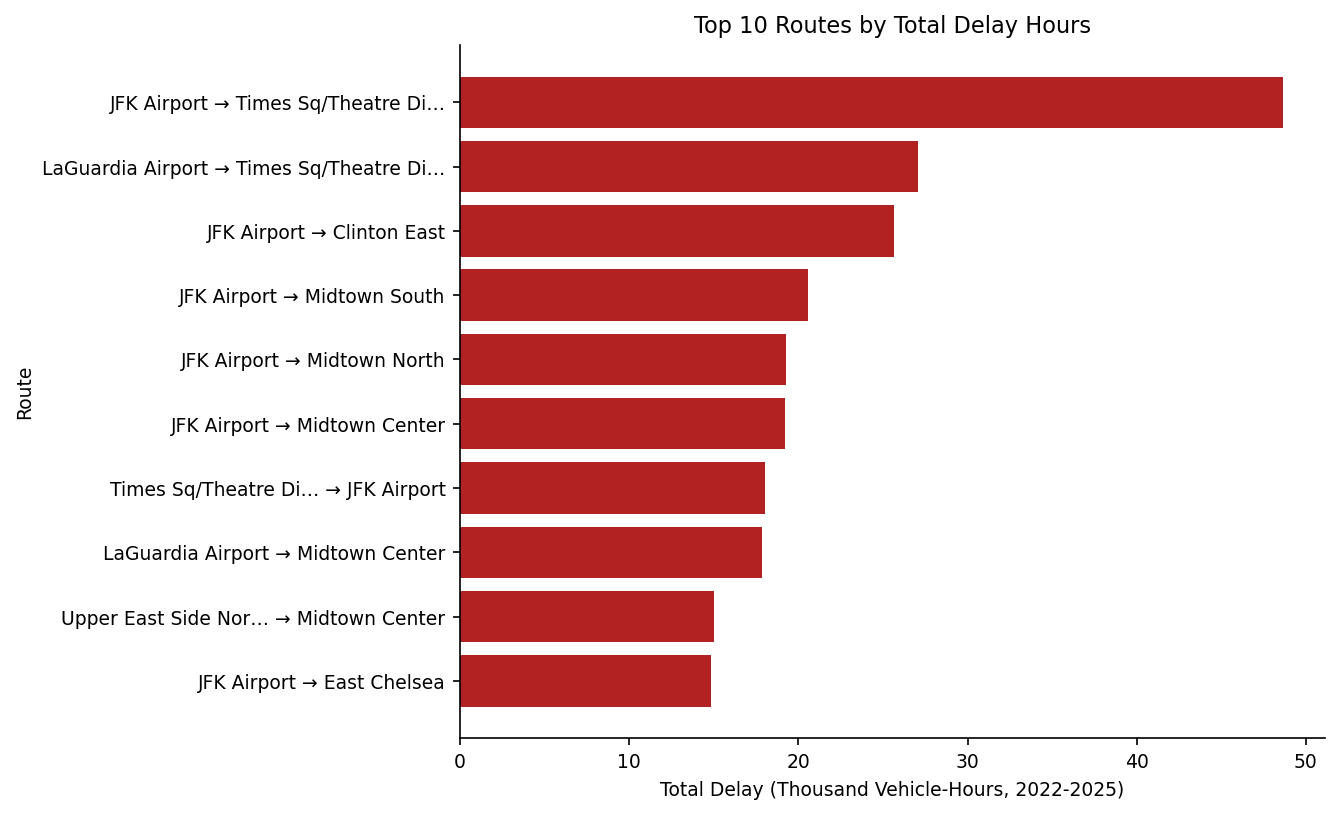

Routes appearing in both top-10 lists: 0 of 10
Top 10 delay-burden routes account for 6% of all peak delay hours.


In [8]:



# FIGURE 2: TOP 10 ROUTES BY TOTAL DELAY HOURS

top_burden = routes.nlargest(10, "delay_hr_total")

fig, ax = plt.subplots(figsize=(9, 5.5))

b = top_burden.iloc[::-1]

ax.barh(
    b["route"],
    b["delay_hr_total"] / 1000,
    color="firebrick"
)

ax.set_xlabel("Total Delay (Thousand Vehicle-Hours, 2022-2025)")
ax.set_ylabel("Route")
ax.set_title("Top 10 Routes by Total Delay Hours")

plt.tight_layout()
save(fig, "fig2_top_delay_routes")
plt.show()


# SUMMARY STATISTICS


overlap = len(
    set(zip(top_tti["pu"], top_tti["do"]))
    &
    set(zip(top_burden["pu"], top_burden["do"]))
)

pos = routes["delay_hr_total"].clip(lower=0)

print(f"Routes appearing in both top-10 lists: {overlap} of 10")

print(
    f"Top 10 delay-burden routes account for "
    f"{pos.nlargest(10).sum() / pos.sum():.0%} "
    f"of all peak delay hours."
)

## Revenue by route

These are the 10 routes earning the most during peak hours, coloured by how congested they are. The label at the end of each bar shows revenue per vehicle-hour. A route can earn a lot in total just because it is busy, so per-hour earnings tell you whether it is actually a good use of a cab's time.

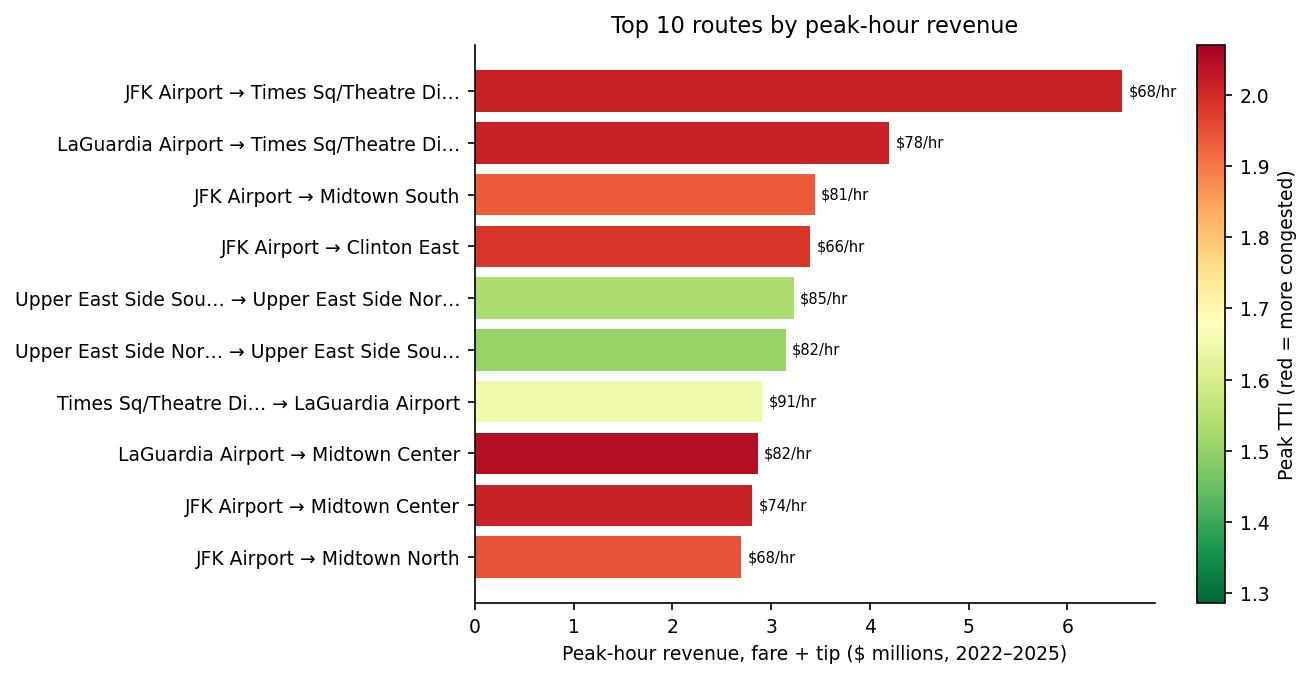

Airport routes in the top 10 by revenue: 8


In [ ]:
top_rev = routes.nlargest(10, "rev").iloc[::-1]
norm = Normalize(routes.tti.quantile(0.05), routes.tti.quantile(0.95))
cmap = plt.cm.RdYlGn_r

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(top_rev.route, top_rev.rev / 1e6, color=cmap(norm(top_rev.tti)))
ax.bar_label(bars, labels=[f"${v:.0f}/hr" for v in top_rev.rev_per_hr], fontsize=7, padding=3)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Peak TTI (red = more congested)")
ax.set_xlabel("Peak-hour revenue, fare + tip ($ millions, 2022–2025)")
ax.set_title("Top 10 routes by peak-hour revenue")
fig.tight_layout()
save(fig, "p2_fig3_revenue_by_route")

print(f"Airport routes in the top 10 by revenue: {top_rev.airport_route.sum()}")

## Congestion vs revenue

**Question: Are congested routes more profitable?** To answer this we look at these two measures:

- **Revenue per trip:** the NYC meter also charges for time when the cab is moving slowly or stopped, so slow trips can earn *more* per trip.
- **Revenue per vehicle-hour:** a slow trip ties up the cab for longer, so it can earn *less* per hour of the driver's time.

Each dot is one route in one peak window. The black line is the median within each TTI decile, which shows the trend without being dominated by outliers. The correlation used is Spearman's ρ, which measures whether one value tends to rise as the other rises and isn't distorted by extreme values.

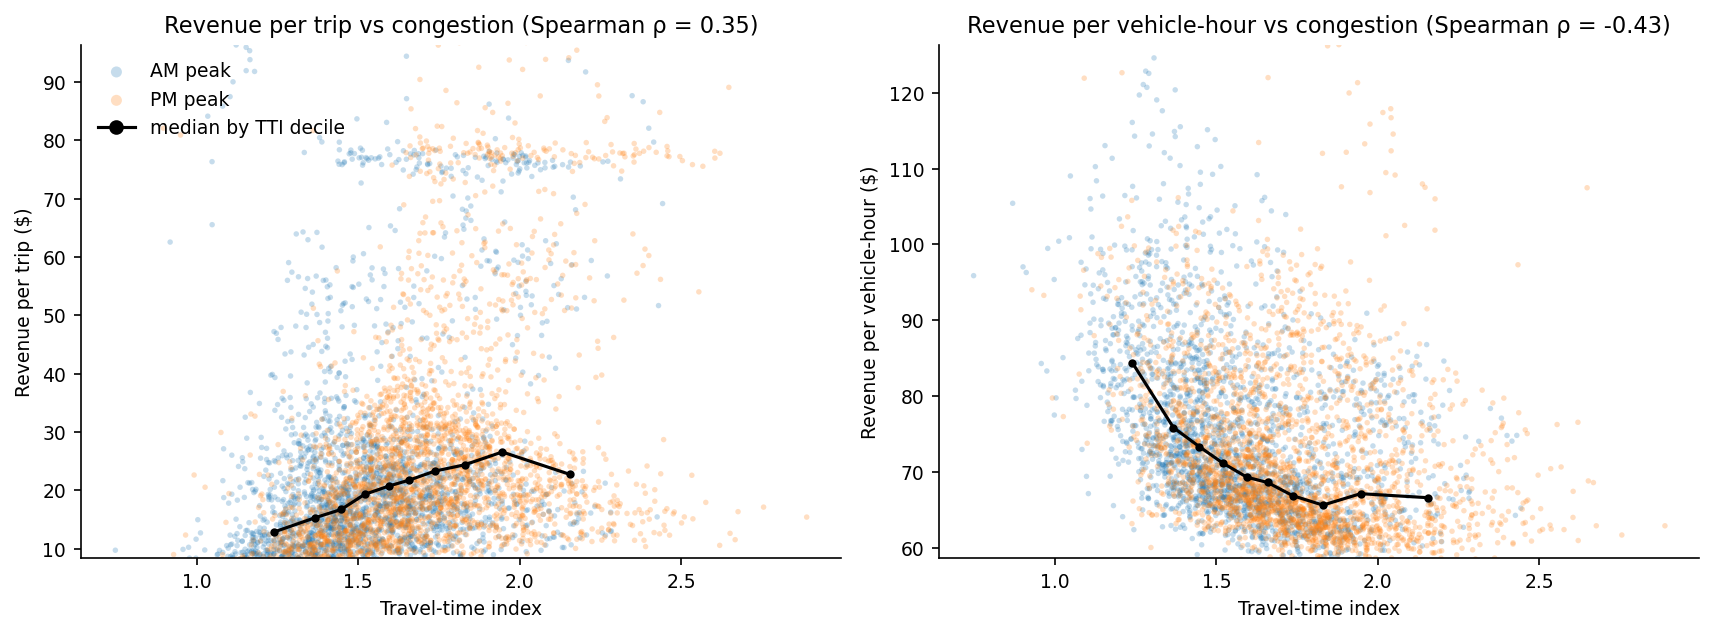

Spearman ρ, TTI vs rev_per_trip: +0.35
Spearman ρ, TTI vs rev_per_hr: -0.43


In [ ]:
def binned(df, col, x="tti", q=10):
    bins = pd.qcut(df[x], q, duplicates="drop")
    return (df.groupby(bins, observed=True)
              .agg(x_mid=(x, "median"), med=(col, "median"), n=(col, "size"))
              .reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
rhos = {}
for ax, col, label in [(axes[0], "rev_per_trip", "Revenue per trip ($)"),
                       (axes[1], "rev_per_hr", "Revenue per vehicle-hour ($)")]:
    for i, (w, wl) in enumerate(PEAKS.items()):
        p = peak[peak.window == w]
        ax.scatter(p.tti, p[col], s=7, alpha=0.25, color=f"C{i}", label=wl, edgecolor="none")
    b = binned(peak, col)
    ax.plot(b.x_mid, b.med, "k-o", ms=3, lw=1.5, label="median by TTI decile")
    rhos[col] = peak[["tti", col]].corr(method="spearman").iloc[0, 1]
    ax.set_ylim(peak[col].quantile(0.01), peak[col].quantile(0.99))
    ax.set_xlabel("Travel-time index"); ax.set_ylabel(label)
    ax.set_title(f"{label.split(' (')[0]} vs congestion (Spearman ρ = {rhos[col]:.2f})")
axes[0].legend(frameon=False, markerscale=2)
fig.tight_layout()
save(fig, "p2_fig4_congestion_vs_revenue")

for col, r in rhos.items():
    print(f"Spearman ρ, TTI vs {col}: {r:+.2f}")